This notebook processes image data. Let's break down each step.

In [2]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# TensorFlow for image preprocessing
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### **Cell 1: Import Libraries**

This cell brings in all the necessary tools and libraries that will be used throughout the notebook. We're importing `os` for working with file paths, `numpy` for numerical operations, `matplotlib.pyplot` for plotting images, `PIL (Pillow)` for image processing, and `tensorflow.keras` for deep learning functionalities like image preprocessing and data augmentation. It also prints the TensorFlow version to confirm it's loaded correctly.

Saving mango dataset.zip.zip to mango dataset.zip.zip
Dataset uploaded successfully!


In [4]:
# ============================================
# CELL 3: EXTRACT ZIP FILE
# ============================================

import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_path = "/content/pepper_dataset" # Changed this line to specify a directory

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:")
print(extract_path)

Dataset extracted to:
/content/pepper_dataset


### **Cell 2: Extract Zip File**

After you've uploaded a zip file containing your images, this cell takes that zipped file and unzips it into a specific folder on your Colab environment. This makes all the individual image files accessible for processing. The `extract_path` variable defines where these files will be stored.

In [5]:
# ============================================
# CELL 4: CHECK DATASET FOLDERS
# ============================================

for root, dirs, files_list in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

pepper_dataset/
  mango dataset/
    Fruit and Vegetable Classification_files/


### **Cell 3: Check Dataset Folders**

This cell helps you get a quick overview of the folder structure after extraction. It walks through the `extract_path` and prints the names of the directories and subdirectories, so you can see how your dataset is organized.

In [6]:
# ============================================
# CELL 5: FIND ALL IMAGE FILES
# ============================================

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

image_paths = []

for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

# Display first 10 image paths
for path in image_paths[:10]:
    print(path)

Total images found: 34
/content/pepper_dataset/mango dataset/Image_1.jpg
/content/pepper_dataset/mango dataset/Image_7.jpg
/content/pepper_dataset/mango dataset/Image_2.jpg
/content/pepper_dataset/mango dataset/Image_4.jpg
/content/pepper_dataset/mango dataset/Image_8.jpg
/content/pepper_dataset/mango dataset/Image_3.jpg
/content/pepper_dataset/mango dataset/Image_6.jpg
/content/pepper_dataset/mango dataset/Image_9.jpg
/content/pepper_dataset/mango dataset/Image_5.jpg
/content/pepper_dataset/mango dataset/Image_10.jpg


### **Cell 4: Find All Image Files**

Here, the notebook searches through all the extracted folders to find every file that ends with common image extensions (like `.jpg`, `.png`, etc.). It creates a list of all these image file paths, so we know exactly where each image is located and how many there are. It also displays the first 10 paths to give you an idea of the file structure.

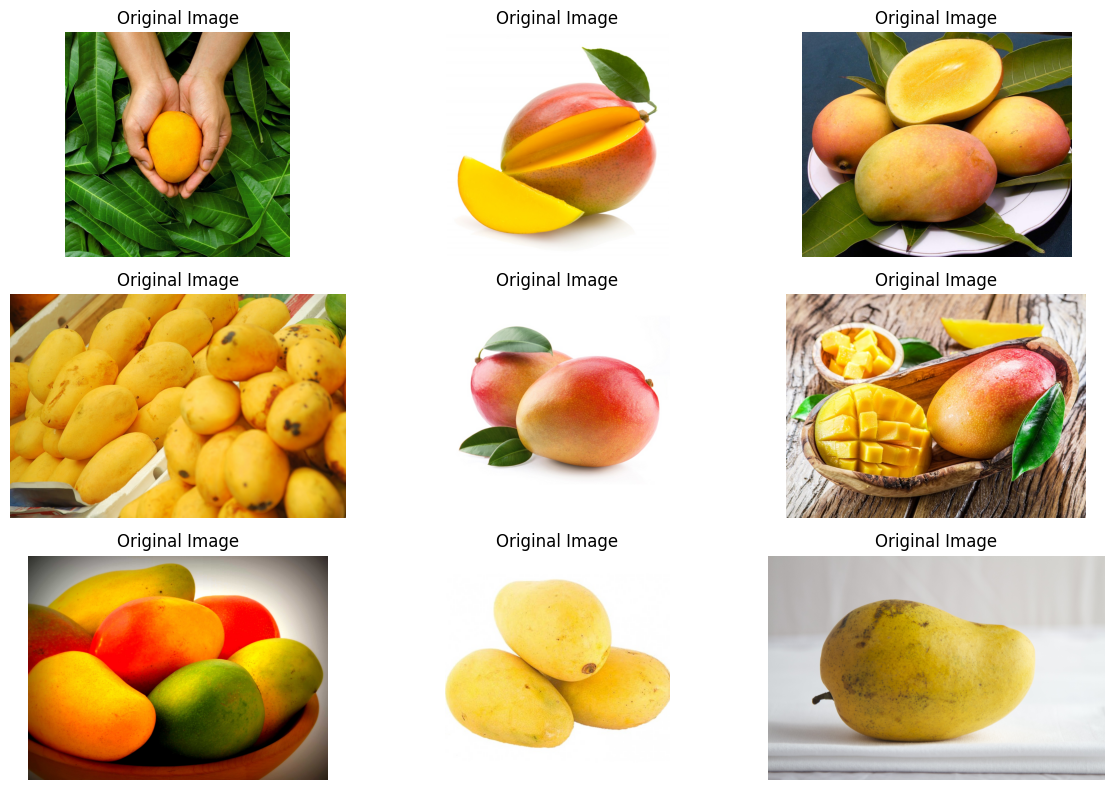

In [7]:
# ============================================
# CELL 6: DISPLAY ORIGINAL IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for i in range(min(9, len(image_paths))):
    img = Image.open(image_paths[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Cell 5: Display Original Images**

This cell is for visual inspection. It takes some of the original images found in the previous step and displays them in a grid. This helps you quickly see what the raw data looks like before any modifications.

In [8]:
# ============================================
# CELL 7: CHECK IMAGE DIMENSIONS
# ============================================

sizes = []

for path in image_paths:
    try:
        img = Image.open(path)
        sizes.append(img.size)
    except:
        pass

print("Number of valid images:", len(sizes))

print("\nFirst 20 image sizes:")

for size in sizes[:20]:
    print(size)

Number of valid images: 34

First 20 image sizes:
(1200, 1200)
(1090, 1100)
(1500, 1250)
(1600, 1071)
(800, 800)
(800, 599)
(3648, 2736)
(600, 600)
(5184, 3456)
(558, 600)
(1200, 1200)
(1090, 1100)
(378, 264)
(100, 100)
(240, 240)
(240, 240)
(1500, 1250)
(240, 240)
(100, 100)
(1600, 1071)


### **Cell 6: Check Image Dimensions**

Images can come in various sizes. This cell opens each image and records its width and height (dimensions). This step is important to understand the variability in your dataset's image sizes, which helps in deciding on a common size for preprocessing. It shows the dimensions of the first 20 images.

In [9]:
# ============================================
# CELL 8: RESIZE IMAGES
# ============================================

IMG_SIZE = (224, 224)

resized_images = []

for path in image_paths:
    try:
        img = Image.open(path).convert("RGB")

        # Resize image
        img_resized = img.resize(IMG_SIZE)

        resized_images.append(np.array(img_resized))

    except Exception as e:
        print("Error:", path, e)

resized_images = np.array(resized_images)

print("Resized dataset shape:")
print(resized_images.shape)

Resized dataset shape:
(34, 224, 224, 3)


### **Cell 7: Resize Images**

To ensure all images can be processed uniformly by a machine learning model, they need to have the same dimensions. This cell resizes all the images to a standard `IMG_SIZE` (224x224 pixels in this case). It also converts them to a numerical format (`numpy` array) and shows the new shape of the entire image dataset.

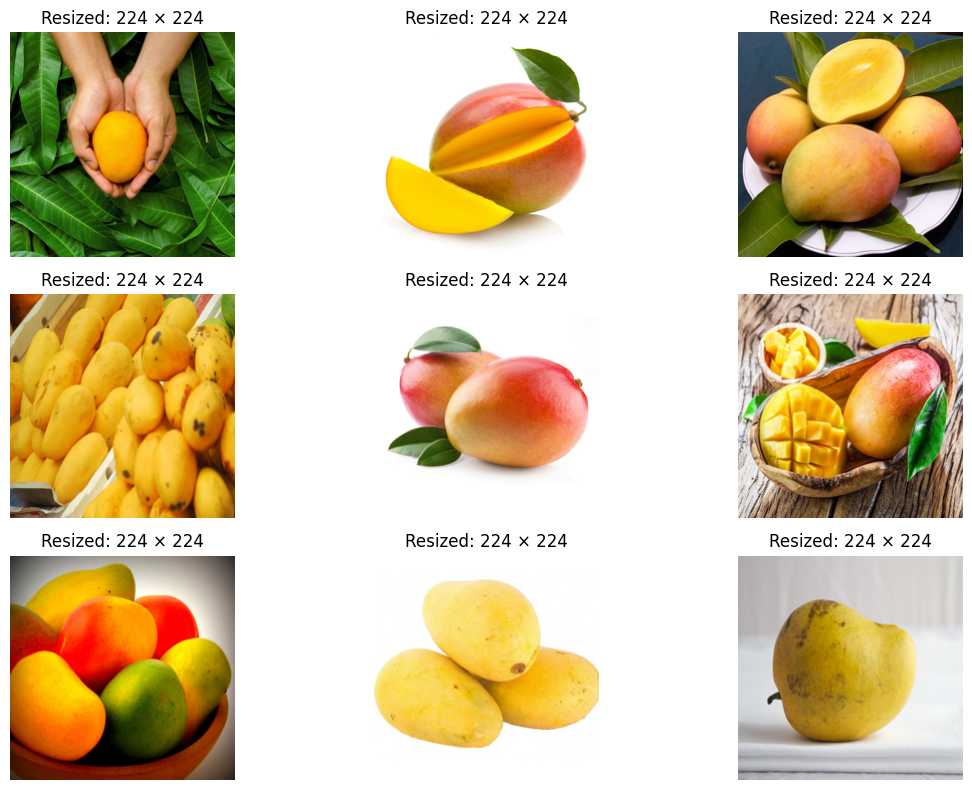

In [10]:
# ============================================
# CELL 9: DISPLAY RESIZED IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for i in range(min(9, len(resized_images))):

    plt.subplot(3, 3, i + 1)
    plt.imshow(resized_images[i])
    plt.title("Resized: 224 × 224")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Cell 8: Display Resized Images**

Similar to displaying original images, this cell shows a few of the images after they have been resized. This confirms that the resizing process worked as expected and the images still look recognizable.

In [11]:
# ============================================
# CELL 10: CONVERT TO FLOAT
# ============================================

resized_images = resized_images.astype("float32")

print("Data type:", resized_images.dtype)

print("Minimum pixel value:", resized_images.min())
print("Maximum pixel value:", resized_images.max())

Data type: float32
Minimum pixel value: 0.0
Maximum pixel value: 255.0


### **Cell 9: Convert to Float**

Most image processing and deep learning models prefer to work with numerical data as floating-point numbers rather than integers. This cell converts the pixel values of the resized images from their original integer format to a `float32` data type. It also checks the minimum and maximum pixel values to ensure the conversion was successful.

In [12]:
# ============================================
# CELL 11: NORMALIZATION
# ============================================

normalized_images = resized_images / 255.0

print("Minimum value:", normalized_images.min())
print("Maximum value:", normalized_images.max())

Minimum value: 0.0
Maximum value: 1.0


### **Cell 10: Normalization**

Normalization is a crucial step in image preprocessing. It scales the pixel values, which are typically between 0 and 255, to a smaller, more manageable range (usually 0 to 1). This helps machine learning models learn more effectively and prevents some pixel values from dominating others. This cell divides all pixel values by 255.0.

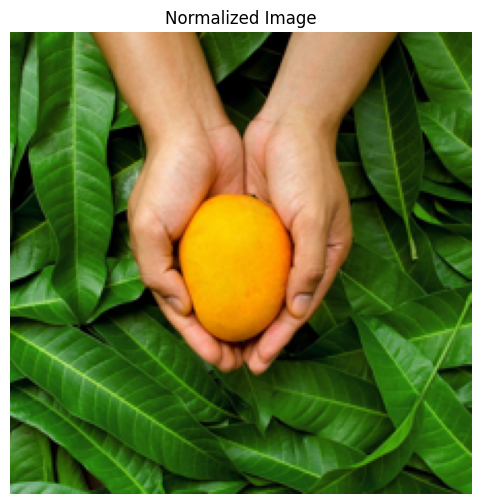

In [13]:
# ============================================
# CELL 12: DISPLAY NORMALIZED IMAGE
# ============================================

plt.figure(figsize=(6, 6))

plt.imshow(normalized_images[0])
plt.title("Normalized Image")
plt.axis("off")

plt.show()

### **Cell 11: Display Normalized Image**

After normalization, this cell displays one of the images again. While visually it might not look much different, the underlying pixel values have been scaled. This step is to confirm the normalization process without visual distortion.

In [14]:
# ============================================
# CELL 13: CHECK FOR CORRUPTED IMAGES
# ============================================

valid_images = []
corrupted_images = []

for path in image_paths:

    try:
        img = Image.open(path)
        img.verify()
        valid_images.append(path)

    except:
        corrupted_images.append(path)

print("Valid images:", len(valid_images))
print("Corrupted images:", len(corrupted_images))

if len(corrupted_images) > 0:
    print("\nCorrupted images:")
    for path in corrupted_images:
        print(path)

Valid images: 34
Corrupted images: 0


### **Cell 12: Check for Corrupted Images**

Sometimes, image files can be damaged or incomplete, which can cause errors during training. This cell tries to open and verify each image file. If an image cannot be opened or is corrupted, it's added to a list of corrupted images. This helps in identifying and potentially removing problematic files from the dataset.

In [15]:
# ============================================
# CELL 14: DATA AUGMENTATION
# ============================================

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

print("Data augmentation created successfully!")

Data augmentation created successfully!


### **Cell 13: Data Augmentation**

Data augmentation is a technique used to artificially expand the training dataset by creating modified versions of existing images. This helps the model become more robust and generalize better to new, unseen data. This cell sets up an `ImageDataGenerator` with various transformations like rotation, shifting, zooming, and flipping. It doesn't apply them yet, just prepares the augmentation strategy.

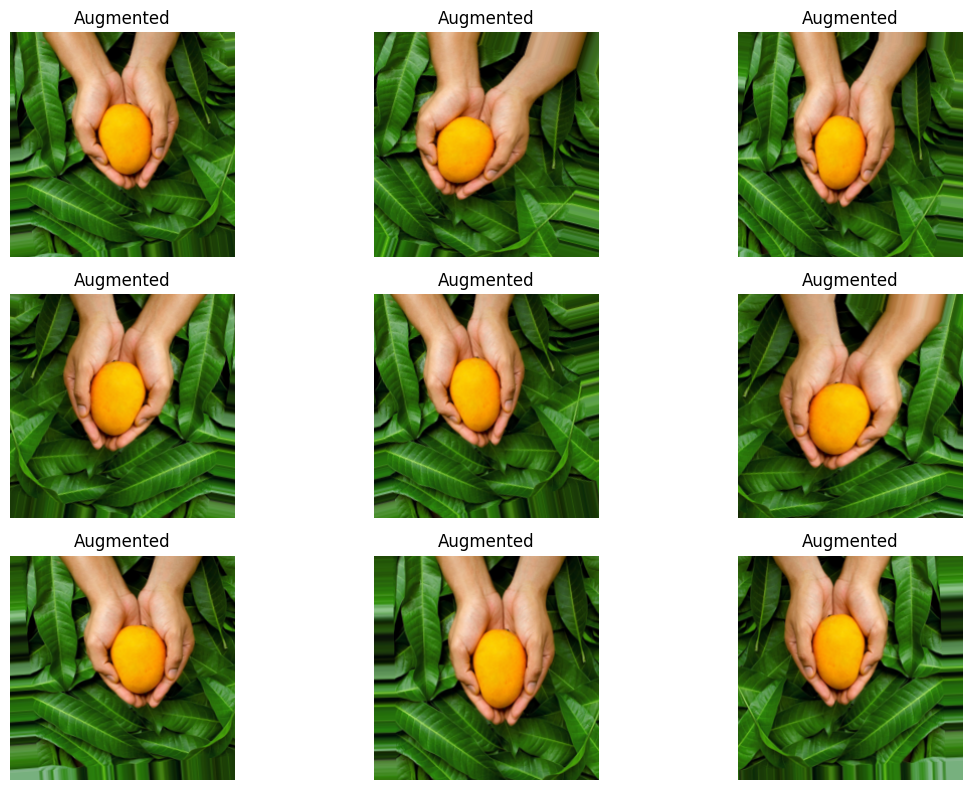

In [16]:
# ============================================
# CELL 15: VISUALIZE AUGMENTED IMAGES
# ============================================

sample_image = resized_images[0]

# Add batch dimension
sample_image = np.expand_dims(sample_image, axis=0)

augmented_images = datagen.flow(
    sample_image,
    batch_size=1
)

plt.figure(figsize=(12, 8))

for i in range(9):

    augmented_image = next(augmented_images)[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image.astype("uint8"))
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Cell 14: Visualize Augmented Images**

To see how the data augmentation works, this cell takes a single sample image and applies the transformations defined in the previous cell. It then displays several augmented versions of that image in a grid, so you can visualize the different random changes that will be applied during training.

In [17]:
# ============================================
# CELL 17: LOAD DATASET USING TENSORFLOW
# ============================================

DATASET_DIR = extract_path

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:")
print(train_dataset.class_names)

Found 34 files belonging to 1 classes.
Using 28 files for training.
Found 34 files belonging to 1 classes.
Using 6 files for validation.
Classes:
['mango dataset']


### **Cell 15: Load Dataset Using TensorFlow**

This cell is a more efficient way to load image datasets directly using TensorFlow's `image_dataset_from_directory` utility. It automatically identifies image classes based on folder names, splits the data into training and validation sets, and prepares them in batches suitable for model training. It also prints the detected class names.

In [18]:
# ============================================
# CELL 18: NORMALIZATION LAYER
# ============================================

normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

normalized_train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

normalized_validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed.")

Normalization completed.


### **Cell 16: Normalization Layer**

Instead of normalizing all images at once, this cell defines a `Rescaling` layer as part of the TensorFlow model preprocessing pipeline. This layer will automatically normalize the pixel values to a 0-1 range when the images are fed into the model during training. This is a more integrated approach to normalization within the TensorFlow ecosystem.

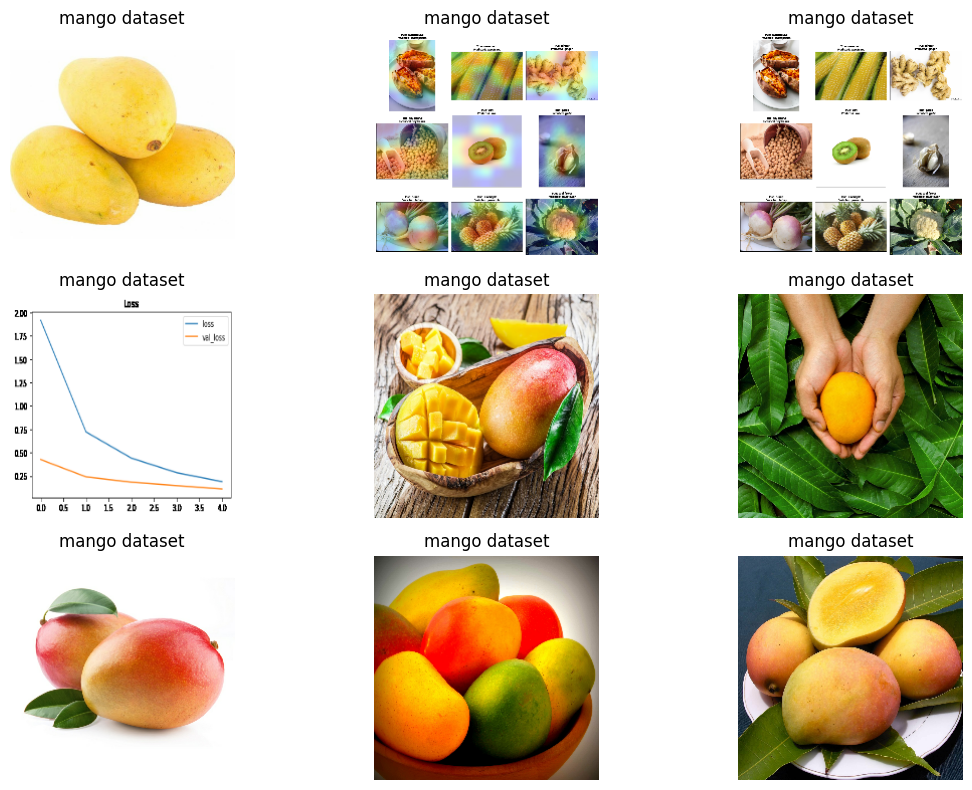

In [19]:
# ============================================
# CELL 19: DISPLAY FINAL PREPROCESSED IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for images, labels in normalized_train_dataset.take(1):

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])
        plt.title(train_dataset.class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

### **Cell 17: Display Final Preprocessed Images**

This final visualization step displays images from the *normalized training dataset* that was prepared using TensorFlow's `image_dataset_from_directory` and the `normalization_layer`. This confirms that the images are correctly loaded, preprocessed, and ready for model training, showing their class labels as titles.